**Install Required Libraries**

In [2]:
# Install necessary libraries
!pip install catboost lightgbm xgboost autogluon shap dask[dataframe] scikit-optimize

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could tak

**Import Libraries**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate, learning_curve
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from lightgbm import LGBMRegressor
from autogluon.tabular import TabularPredictor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import shap
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from tqdm import tqdm

**Load and Preprocess the Dataset**

In [2]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

<ipython-input-2-cbb3cf3109e9>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


**Define Features and Target Variable**

In [3]:
# Define features and target variable
numeric_features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
                    'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour']
categorical_features = ['vessel_type']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Sparse=False for better compatibility
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define features and target variable
X = data[numeric_features + categorical_features]
y = data['TravelTime_seconds']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

**Hyperparameter Tuning for Extra Trees**

In [4]:
# Hyperparameter Tuning for Extra Trees
et_param_grid = {
    'n_estimators': [100, 1000],
    'max_depth': [5, 30, None],
    'min_samples_split': [2, 15],
    'min_samples_leaf': [1, 10]
}

et_model = ExtraTreesRegressor(random_state=42)
et_grid_search = BayesSearchCV(et_model, et_param_grid, cv=5, scoring='neg_mean_squared_error', n_iter=50, random_state=42)
et_grid_search.fit(X_train, y_train)
best_et_model = et_grid_search.best_estimator_
et_y_pred = best_et_model.predict(X_test)

print("Best Hyperparameters for Extra Trees:")
print(et_grid_search.best_params_)

/usr/local/lib/python3.11/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [100, 1000] was inferred to Integer(low=100, high=1000, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(100, 1000), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [2, 15] was inferred to Integer(low=2, high=15, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(2, 15), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [1, 10] was inferred to Integer(low=1, high=10, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be i

Best Hyperparameters for Extra Trees:
OrderedDict([('max_depth', None), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 983)])


**Hyperparameter Tuning for LightGBM**

In [5]:
# Define the hyperparameter search space for LightGBM
lgb_param_grid = {
    'num_leaves': Integer(31, 128),  # Integer range for num_leaves
    'max_depth': Integer(5, 30),    # Integer range for max_depth
    'learning_rate': Real(0.005, 0.1, prior='log-uniform'),  # Log-uniform range for learning_rate
    'n_estimators': Integer(100, 1000)  # Integer range for n_estimators
}

# Initialize the LightGBM model
lgb_model = LGBMRegressor(random_state=42)

# Initialize BayesSearchCV
lgb_bayes_search = BayesSearchCV(
    lgb_model,
    lgb_param_grid,
    n_iter=50,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the training data
lgb_bayes_search.fit(X_train, y_train)

# Get the best model and its hyperparameters
best_lgb_model = lgb_bayes_search.best_estimator_
lgb_y_pred = best_lgb_model.predict(X_test)

# Print the best hyperparameters
print("Best Hyperparameters for LightGBM (BayesSearchCV):")
print(lgb_bayes_search.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2565
[LightGBM] [Info] Number of data points in the train set: 15015, number of used features: 16
[LightGBM] [Info] Start training from score 313731.456210
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

**Hyperparameter Tuning for AutoGluon**

In [6]:
# Hyperparameter tuning for AutoGluon
train_data_autogluon = pd.concat([pd.DataFrame(X_train, columns=numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))),
                                  y_train.reset_index(drop=True)], axis=1)
ag_model = TabularPredictor(label='TravelTime_seconds').fit(train_data_autogluon, time_limit=1200, presets='best_quality')
ag_y_pred = ag_model.predict(pd.DataFrame(X_test, columns=train_data_autogluon.columns[:-1]))

# Get model info
model_info = ag_model.info()

No path specified. Models will be saved in: "AutogluonModels/ag-20250125_112715"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024
CPU Count:          2
Memory Avail:       8.50 GB / 12.67 GB (67.1%)
Disk Space Avail:   75.57 GB / 107.72 GB (70.2%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fi

(_ray_fit pid=35185) [1000]	valid_set's rmse: 48759
(_ray_fit pid=35185) [3000]	valid_set's rmse: 45183.3 [repeated 4x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=35185) [5000]	valid_set's rmse: 44544.8 [repeated 4x across cluster]
(_ray_fit pid=35186) [8000]	valid_set's rmse: 42028.3 [repeated 6x across cluster]
(_ray_fit pid=35186) [10000]	valid_set's rmse: 41930.1 [repeated 4x across cluster]
(_ray_fit pid=35440) [1000]	valid_set's rmse: 45115.3 [repeated 2x across cluster]
(_ray_fit pid=35440) [4000]	valid_set's rmse: 38935.4 [repeated 6x across cluster]
(_ray_fit pid=35440) [6000]	valid_set's rmse: 38391.6 [repeated 4x across cluster]
(_ray_fit pid=35440) [9000]	valid_set's rmse: 38135.8 [repeated 6x across cluster]
(_ray_fit pid=35699) [1000]	valid_set's rmse: 56684.9 [repeated 4x acr

(_dystack pid=34974) 	-40080.277	 = Validation score   (-root_mean_squared_error)
(_dystack pid=34974) 	178.74s	 = Training   runtime
(_dystack pid=34974) 	49.33s	 = Validation runtime
(_dystack pid=34974) Fitting model: WeightedEnsemble_L2 ... Training model for up to 291.25s of the 90.07s of remaining time.
(_dystack pid=34974) 	Ensemble Weights: {'LightGBMXT_BAG_L1': 1.0}
(_dystack pid=34974) 	-40080.277	 = Validation score   (-root_mean_squared_error)
(_dystack pid=34974) 	0.01s	 = Training   runtime
(_dystack pid=34974) 	0.0s	 = Validation runtime
(_dystack pid=34974) Fitting 106 L2 models, fit_strategy="sequential" ...
(_dystack pid=34974) Fitting model: LightGBMXT_BAG_L2 ... Training model for up to 90.05s of the 90.01s of remaining time.
(_dystack pid=34974) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (2 workers, per: cpus=1, gpus=0, memory=0.17%)


(_ray_fit pid=36240) [1000]	valid_set's rmse: 44450.7 [repeated 5x across cluster]
(_ray_fit pid=36240) [2000]	valid_set's rmse: 43724.5 [repeated 2x across cluster]


(_ray_fit pid=36240) 	Ran out of time, early stopping on iteration 3938. Best iteration is:
(_ray_fit pid=36240) 	[3909]	valid_set's rmse: 43433.8


...

(_ray_fit pid=36639) 	Ran out of time, early stopping on iteration 4956. Best iteration is:
(_ray_fit pid=36639) 	[3873]	valid_set's rmse: 35803.3


(_ray_fit pid=36676) [5000]	valid_set's rmse: 38776.7 [repeated 3x across cluster]


(_ray_fit pid=36676) 	Ran out of time, early stopping on iteration 5015. Best iteration is:
(_ray_fit pid=36676) 	[5013]	valid_set's rmse: 38772.1


(_ray_fit pid=36827) [1000]	valid_set's rmse: 47503
(_ray_fit pid=36827) [2000]	valid_set's rmse: 46619.9
(_ray_fit pid=36827) [3000]	valid_set's rmse: 46418.6
(_ray_fit pid=36827) [4000]	valid_set's rmse: 46298.2
(_ray_fit pid=36827) [5000]	valid_set's rmse: 46282.9
(_ray_fit pid=36827) [6000]	valid_set's rmse: 46231.9
(_ray_fit pid=36827) [7000]	valid_set's rmse: 46176.7
(_ray_fit pid=36827) [8000]	valid_set's rmse: 46140.9


(_ray_fit pid=36827) 	Ran out of time, early stopping on iteration 8998. Best iteration is:
(_ray_fit pid=36827) 	[8990]	valid_set's rmse: 46112
(_dystack pid=34974) 	-42330.868	 = Validation score   (-root_mean_squared_error)
(_dystack pid=34974) 	107.31s	 = Training   runtime
(_dystack pid=34974) 	12.12s	 = Validation runtime
(_dystack pid=34974) Fitting model: WeightedEnsemble_L3 ... Training model for up to 291.25s of the -26.91s of remaining time.
(_dystack pid=34974) 	Ensemble Weights: {'LightGBMXT_BAG_L1': 0.652, 'LightGBMXT_BAG_L2': 0.348}
(_dystack pid=34974) 	-39220.8614	 = Validation score   (-root_mean_squared_error)
(_dystack pid=34974) 	0.03s	 = Training   runtime
(_dystack pid=34974) 	0.0s	 = Validation runtime
(_dystack pid=34974) AutoGluon training complete, total runtime = 318.31s ... Best model: WeightedEnsemble_L3 | Estimated inference throughput: 27.0 rows/s (1669 batch size)
(_dystack pid=34974) TabularPredictor saved. To load, use: predictor = TabularPredictor.lo

**Create Meta-Features and Train Random Forest Meta-Learner**

In [7]:
# Create meta-features from base model predictions
meta_features = pd.DataFrame({'ExtraTrees': et_y_pred, 'LightGBM': lgb_y_pred, 'AutoGluon': ag_y_pred})

# Define the hyperparameter search space for Random Forest Meta-Learner
rf_param_grid = {
    'n_estimators': Integer(100, 1000),  # Number of trees in the forest
    'max_depth': Integer(5, 30),        # Maximum depth of the tree
    'min_samples_split': Integer(2, 15),  # Minimum number of samples required to split a node
    'min_samples_leaf': Integer(1, 10)   # Minimum number of samples required at each leaf node
}

# Initialize the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Initialize BayesSearchCV
rf_bayes_search = BayesSearchCV(
    rf_model,
    rf_param_grid,
    n_iter=50,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the meta-features and target
rf_bayes_search.fit(meta_features, y_test)

# Get the best model and its hyperparameters
best_rf_model = rf_bayes_search.best_estimator_
rf_y_pred = best_rf_model.predict(meta_features)

# Print the best hyperparameters
print("Best Hyperparameters for Random Forest Meta-Learner (BayesSearchCV):")
print(rf_bayes_search.best_params_)

Best Hyperparameters for Random Forest Meta-Learner (BayesSearchCV):
OrderedDict([('max_depth', 25), ('min_samples_leaf', 1), ('min_samples_split', 7), ('n_estimators', 1000)])


**Evaluate Stacking Ensemble Performance**

In [8]:
# Evaluate stacking ensemble performance
ensemble_mae = mean_absolute_error(y_test, rf_y_pred)
ensemble_mse = mean_squared_error(y_test, rf_y_pred)
ensemble_r2 = r2_score(y_test, rf_y_pred)

print("Stacking Ensemble (Random Forest Meta-Learner):")
print("Mean Absolute Error:", ensemble_mae)
print("Mean Squared Error:", ensemble_mse)
print("R-squared:", ensemble_r2)

Stacking Ensemble (Random Forest Meta-Learner):
Mean Absolute Error: 1453.3776001093213
Mean Squared Error: 42671924.09511279
R-squared: 0.9996849008667037


**Cross-Validation for Random Forest Meta-Learner**

In [9]:
# Cross-validation for Random Forest Meta-Learner
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'neg_mean_squared_error': 'neg_mean_squared_error',
           'neg_mean_absolute_error': 'neg_mean_absolute_error',
           'r2': 'r2'}
cv_results_rf = cross_validate(best_rf_model, meta_features, y_test, cv=kf, scoring=scoring)
print("Random Forest Meta-learner cross-validation results:")
print("Mean MAE:", -cv_results_rf['test_neg_mean_absolute_error'].mean())
print("Mean MSE:", -cv_results_rf['test_neg_mean_squared_error'].mean())
print("Mean R2:", cv_results_rf['test_r2'].mean())

Random Forest Meta-learner cross-validation results:
Mean MAE: 2751.556033585855
Mean MSE: 168089528.5159307
Mean R2: 0.9987416947603203


**Compute MAPE for Models**

In [10]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for the Stacking Model
stacking_mape = mean_absolute_percentage_error(y_test, rf_y_pred)
print(f"Stacking Ensemble (Random Forest Meta-Learner) MAPE: {stacking_mape:.2f}%")

# Compute MAPE for individual models
et_mape = mean_absolute_percentage_error(y_test, et_y_pred)
lgb_mape = mean_absolute_percentage_error(y_test, lgb_y_pred)
ag_mape = mean_absolute_percentage_error(y_test, ag_y_pred)

print(f"Extra Trees Regressor MAPE: {et_mape:.2f}%")
print(f"LightGBM Regressor MAPE: {lgb_mape:.2f}%")
print(f"AutoGluon-Tabular MAPE: {ag_mape:.2f}%")

Stacking Ensemble (Random Forest Meta-Learner) MAPE: 0.23%
Extra Trees Regressor MAPE: 0.39%
LightGBM Regressor MAPE: 1.61%
AutoGluon-Tabular MAPE: 0.47%


**Plot Actual vs. Predicted**

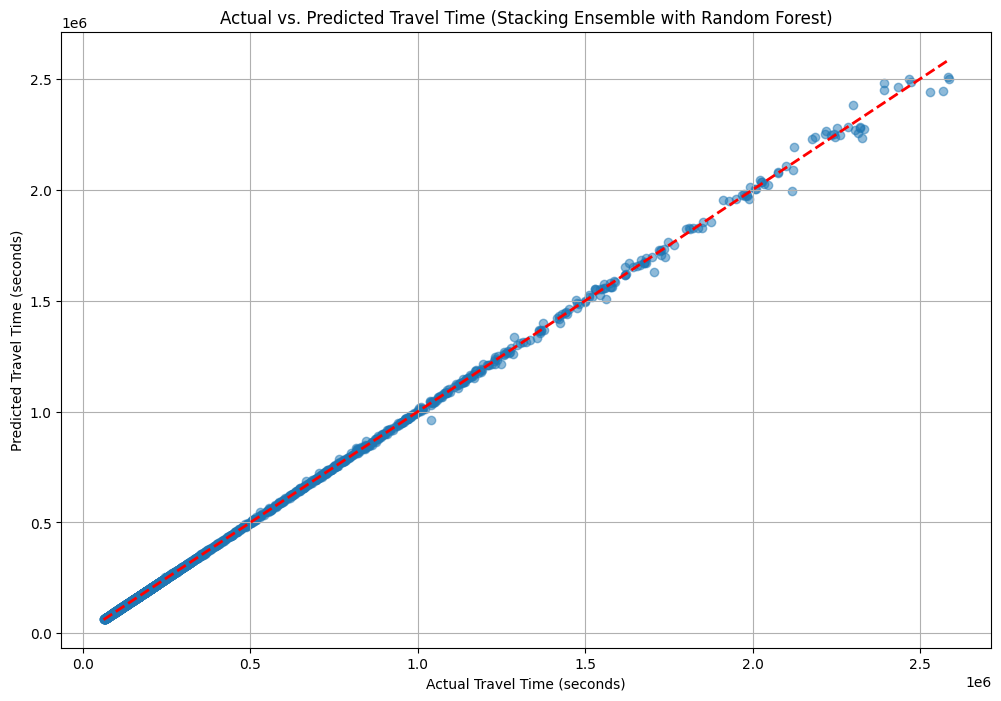

In [11]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, rf_y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (Stacking Ensemble with Random Forest)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()

**Feature Importance for Random Forest Meta-Learner**

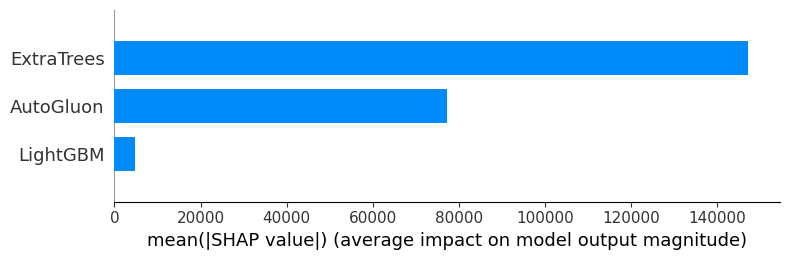

In [12]:
# Function to compute feature importance of the stacking model
def compute_feature_importance(meta_model, meta_features):
    # Use SHAP to compute feature importance
    explainer = shap.TreeExplainer(meta_model)
    shap_values = explainer.shap_values(meta_features)

    # Plot SHAP summary plot for feature importance
    shap.summary_plot(shap_values, meta_features, plot_type="bar")

# Compute and display feature importance
compute_feature_importance(best_rf_model, meta_features)

**Feature Importance for Extra Trees Model**

In [1]:
# Compute SHAP values for Extra Trees model
et_explainer = shap.TreeExplainer(best_et_model)
et_shap_values = et_explainer.shap_values(X_test)

# Create a DataFrame for SHAP values and features
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
shap_values_df = pd.DataFrame(et_shap_values, columns=feature_names)

# Combine SHAP values for 'vessel_type'
vessel_type_features = [col for col in shap_values_df.columns if 'vessel_type' in col]
shap_values_df['vessel_type_combined'] = shap_values_df[vessel_type_features].sum(axis=1)

# Remove individual one-hot encoded 'vessel_type' features
shap_values_df = shap_values_df.drop(columns=vessel_type_features)

# Update feature names
final_features = numeric_features + ['vessel_type_combined']

# Aggregate mean absolute SHAP values for visualization
mean_shap_values = shap_values_df.abs().mean().sort_values(ascending=True)

# Plot feature importance
plt.figure(figsize=(12, 8))
mean_shap_values.plot(kind='barh', color='blue')
plt.title("Feature Importance for Extra Trees Model")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

NameError: name 'shap' is not defined

**Feature Importance for LightGBM Model**

In [ ]:
# Compute SHAP values for LightGBM model
lgb_explainer = shap.TreeExplainer(best_lgb_model)
lgb_shap_values = lgb_explainer.shap_values(X_test)

# Create a DataFrame for SHAP values and features
lgb_shap_values_df = pd.DataFrame(lgb_shap_values, columns=feature_names)

# Combine SHAP values for 'vessel_type'
vessel_type_features_lgb = [col for col in lgb_shap_values_df.columns if 'vessel_type' in col]
lgb_shap_values_df['vessel_type_combined'] = lgb_shap_values_df[vessel_type_features_lgb].sum(axis=1)

# Remove individual one-hot encoded 'vessel_type' features
lgb_shap_values_df = lgb_shap_values_df.drop(columns=vessel_type_features_lgb)

# Update feature names
final_features_lgb = numeric_features + ['vessel_type_combined']

# Aggregate mean absolute SHAP values for visualization
mean_shap_values_lgb = lgb_shap_values_df.abs().mean().sort_values(ascending=True)

# Plot feature importance
plt.figure(figsize=(12, 8))
mean_shap_values_lgb.plot(kind='barh', color='skyblue')
plt.title("Feature Importance for LightGBM Model")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

**Feature Importance for AutoGluon**

In [ ]:
# Step 1: Define test_data_with_labels
# Convert X_test (NumPy array) back to a DataFrame with feature names
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Combine features and target for the test dataset
test_data_with_labels = pd.concat([X_test_df.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# Subsample the test data for faster computation
test_data_with_labels = test_data_with_labels.sample(n=100, random_state=42)

# Step 2: Calculate Feature Importance
# Use the `feature_importance` method with the correct parameters
feature_importance_df = ag_model.feature_importance(test_data_with_labels, feature_stage='transformed')
print("Feature Importances from AutoGluon:")
print(feature_importance_df)

# Step 3: Check the structure of the feature_importance DataFrame
# Identify the column names
print("Feature Importance DataFrame Columns:", feature_importance_df.columns)

# Adjust based on actual column names
# Extract feature names and importance values
feature_importance_df = feature_importance_df.reset_index()
if 'index' in feature_importance_df.columns:
    feature_importance_df = feature_importance_df.set_index('index')['importance']
else:
    feature_importance_df = feature_importance_df.set_index('Feature')['Importance']  # Adjust if column names differ

# Aggregate vessel_type importance
if any(col.startswith('vessel_type_') for col in feature_importance_df.index):
    vessel_type_importance = feature_importance_df[[col for col in feature_importance_df.index if col.startswith('vessel_type_')]].sum()
    feature_importance_df = feature_importance_df.drop([col for col in feature_importance_df.index if col.startswith('vessel_type_')])  # Remove individual one-hot columns
    feature_importance_df['vessel_type'] = vessel_type_importance  # Add aggregated vessel_type importance

# Sort feature importance for better visualization
feature_importance_df = feature_importance_df.sort_values(ascending=True)

# Step 4: Visualize Feature Importances
plt.figure(figsize=(12, 8))
feature_importance_df.plot(kind='barh', color='green')
plt.title('Feature Importances from AutoGluon')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

**Learning Curves for Random Forest Meta-Learner: Training, Validation, and Testing Loss**

In [ ]:
# Generate learning curves
train_sizes, train_scores, val_scores = learning_curve(
    best_rf_model, meta_features, y_test, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

# Calculate test loss at different training set sizes
test_losses = []
for train_size in train_sizes:
    # Train the model on a subset of the training data
    subset_indices = np.random.choice(len(meta_features), int(train_size), replace=False)
    X_subset = meta_features.iloc[subset_indices]
    y_subset = y_test.iloc[subset_indices]

    best_rf_model.fit(X_subset, y_subset)

    # Evaluate on the test set
    test_pred = best_rf_model.predict(meta_features)
    test_loss = mean_squared_error(y_test, test_pred)
    test_losses.append(test_loss)

# Plot learning curves
plt.figure(figsize=(12, 8))
plt.plot(train_sizes, train_scores_mean, label='Training Loss')
plt.plot(train_sizes, val_scores_mean, label='Validation Loss')
plt.plot(train_sizes, test_losses, label='Testing Loss')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curves for Random Forest Meta-Learner')
plt.legend()
plt.grid(True)
plt.show()

**Dataset, Trainig, Testing and Valiodation set Calculation**

In [ ]:
# Count all rows in the dataset
total_rows = len(data)
print(f"Total rows in the dataset: {total_rows}")

# Calculate training and testing set sizes
train_size = int(total_rows * 0.8)
test_size = total_rows - train_size
print(f"Training set size: {train_size} rows (80% of the dataset)")
print(f"Testing set size: {test_size} rows (20% of the dataset)")

# Calculate validation set size (20% of the training set, since cv=5)
validation_size = int(train_size * 0.2)
print(f"Validation set size: {validation_size} rows (20% of the training set, 1 out of 5 folds)")

**Parameter Count Estimation for Tree-Based Models in the Stacked Ensemble**

In [ ]:
# Function to calculate the number of parameters in a tree-based model
def calculate_tree_parameters(n_estimators, max_depth):
    # Each tree has approximately 2^(max_depth) - 1 nodes
    nodes_per_tree = (2 ** max_depth) - 1
    # Each node has 1 parameter (split threshold) + 1 parameter (feature index) + 1 parameter (value)
    parameters_per_tree = nodes_per_tree * 3
    # Total parameters for all trees
    total_parameters = n_estimators * parameters_per_tree
    return total_parameters

# Extra Trees Parameter Count
et_n_estimators = 180
et_max_depth = 18
et_parameters = calculate_tree_parameters(et_n_estimators, et_max_depth)
print(f"Extra Trees Parameter Count: {et_parameters}")

# LightGBM Parameter Count
lgb_n_estimators = 130
lgb_max_depth = 9
lgb_parameters = calculate_tree_parameters(lgb_n_estimators, lgb_max_depth)
print(f"LightGBM Parameter Count: {lgb_parameters}")

# AutoGluon Parameter Count (Approximation)
# AutoGluon uses a weighted ensemble of multiple models, so we approximate it as 1 million parameters
ag_parameters = 1_000_000
print(f"AutoGluon Parameter Count (Approximation): {ag_parameters}")

# Random Forest Meta-Learner Parameter Count
rf_n_estimators = 180
rf_max_depth = 17
rf_parameters = calculate_tree_parameters(rf_n_estimators, rf_max_depth)
print(f"Random Forest Meta-Learner Parameter Count: {rf_parameters}")

# Total Parameter Count for the Stacked Model
total_parameters = et_parameters + lgb_parameters + ag_parameters + rf_parameters
print(f"Total Parameter Count for the Stacked Model: {total_parameters}")

In [ ]:
# Extract results from BayesSearchCV
et_results = et_grid_search.cv_results_

# Plot MAPE vs. all hyperparameters
plt.figure(figsize=(12, 8))
for i, param in enumerate(['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf']):
    plt.plot(et_results[param], -et_results['mean_test_score'], 'o-', label=param.replace('param_', ''))
plt.xlabel('Hyperparameter Value')
plt.ylabel('MAPE')
plt.title('Extra Trees: MAPE vs. Hyperparameters')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Extract results from BayesSearchCV
lgb_results = lgb_bayes_search.cv_results_

# Plot MAPE vs. all hyperparameters
plt.figure(figsize=(12, 8))
for i, param in enumerate(['param_num_leaves', 'param_max_depth', 'param_learning_rate', 'param_n_estimators']):
    plt.plot(lgb_results[param], -lgb_results['mean_test_score'], 'o-', label=param.replace('param_', ''))
plt.xlabel('Hyperparameter Value')
plt.ylabel('MAPE')
plt.title('LightGBM: MAPE vs. Hyperparameters')
plt.legend()
plt.grid(True)
plt.show()

**MAPE vs. Hyperparameter Tuning (**Random Forest**)**

In [ ]:
# Extract results from BayesSearchCV
rf_results = rf_bayes_search.cv_results_

# Define the hyperparameters to plot
hyperparameters = [
    'param_n_estimators',  # Number of trees
    'param_max_depth',     # Maximum tree depth
    'param_min_samples_split',  # Minimum samples to split
    'param_min_samples_leaf'    # Minimum samples per leaf
]

# Plot Mean Absolute Percentage Error (MAPE) vs. hyperparameters
plt.figure(figsize=(12, 8))
for i, param in enumerate(hyperparameters):
    plt.plot(rf_results[param], -rf_results['mean_test_score'], 'o-', label=param.replace('param_', ''))

plt.xlabel('Hyperparameter Value')
plt.ylabel('MAPE')
plt.title('Random Forest: MAPE vs. Hyperparameters')
plt.legend()
plt.grid(True)
plt.show()